# FlySky FS-i6X + Receiver — Automated Health and Manufacturing Test

**An Arduino Mega 2560 test station that measures the PWM outputs of an RC receiver, guides the
operator step by step and produces a health report with a diagnostic score (0–100).**

| | |
|---|---|
| System under test | FlySky FS-i6X transmitter + PWM receiver (e.g. FS-iA6B) |
| Test station | Arduino Mega 2560 + computer with the Arduino IDE Serial Monitor |
| Inputs | receiver CH1–CH4 PWM signals on Arduino pins 2, 3, 4, 5 |
| Serial Monitor | 115200 baud, line ending **Newline** |
| Sketch | [`flysky_health_test/flysky_health_test.ino`](flysky_health_test/flysky_health_test.ino) |

> ⚠️ **REMOVE ALL PROPELLERS.** The test switches the transmitter off on purpose to observe the failsafe.

### Contents
1. Objective
2. What the test can — and cannot — measure
3. Safety
4. Wiring
5. The RC PWM signal
6. How the Arduino measures PWM (`pulseIn`) and the timing budget
7. The test sequence
8. Statistics: availability, mean, standard deviation (Welford)
9. The scoring system
10. TEST 8 — distance / live-link test with time windows
11. TEST 9 — failsafe test
12. TEST 10 — link recovery
13. How to run the test
14. The final report
15. Testing many units (CSV line)
16. Code review: what was checked and fixed
17. How the code was verified
18. Distance does not change the PWM width
19. Towards a real RF test (RSSI / i-BUS)
20. References

## 1. Objective

The program turns the Arduino Mega into an **automated test station** for the FlySky remote-control
system. The complete chain under test is:

**FS-i6X transmitter → 2.4 GHz RF → FlySky receiver → PWM CH1–CH4 → Arduino Mega → USB → Serial Monitor**

The Arduino guides the operator: leave the sticks neutral, move each stick to both end points, keep
still for a stability test, walk away for a distance test, switch the transmitter off (failsafe) and on
again (recovery). It then analyses

* receiver connection and PWM validity
* center positions, stick end points and total travel
* channel stability (jitter) and missing pulses
* live command response at distance
* link-loss (failsafe) behavior and signal recovery

and prints a health report with a **diagnostic score**.

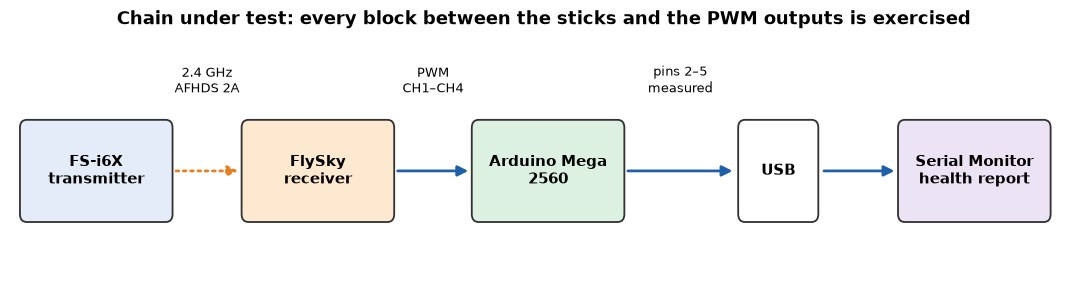

In [1]:
# Common setup for the diagrams of this notebook
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

os.makedirs("images", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

C = {"tx": "#e3ecf8", "rx": "#fde9cf", "arduino": "#dcf1e2", "pc": "#ece3f5",
     "blue": "#1f5fa8", "red": "#c0392b", "green": "#2e8b57", "orange": "#e67e22", "grey": "#7f8c8d"}


def box(ax, x, y, w, h, text, color, fontsize=10, bold=False):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=color, ec="#333333", lw=1.2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            fontweight="bold" if bold else "normal")


def arrow(ax, x1, y1, x2, y2, color="#333333", ls="-", lw=1.8):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=14, color=color, lw=lw, linestyle=ls))


fig, ax = plt.subplots(figsize=(12.5, 2.9))
ax.set_xlim(0, 12.5)
ax.set_ylim(0.6, 3.1)
ax.axis("off")
chain = [(1.0, "FS-i6X\ntransmitter", C["tx"]), (3.6, "FlySky\nreceiver", C["rx"]),
         (6.3, "Arduino Mega\n2560", C["arduino"]), (9.0, "USB", "#ffffff"), (11.3, "Serial Monitor\nhealth report", C["pc"])]
for x, text, color in chain:
    box(ax, x, 1.7, 1.75 if text != "USB" else 0.9, 1.0, text, color, fontsize=9.5, bold=True)
arrow(ax, 1.9, 1.7, 2.7, 1.7, C["orange"], ls=":")
ax.text(2.3, 2.5, "2.4 GHz\nAFHDS 2A", ha="center", fontsize=8.5)
arrow(ax, 4.5, 1.7, 5.4, 1.7, C["blue"])
ax.text(4.95, 2.5, "PWM\nCH1–CH4", ha="center", fontsize=8.5)
arrow(ax, 7.2, 1.7, 8.5, 1.7, C["blue"])
ax.text(7.85, 2.5, "pins 2–5\nmeasured", ha="center", fontsize=8.5)
arrow(ax, 9.5, 1.7, 10.4, 1.7, C["blue"])
ax.set_title("Chain under test: every block between the sticks and the PWM outputs is exercised",
             fontsize=11.5, fontweight="bold")
fig.savefig("images/test_chain.png", bbox_inches="tight")
plt.show()

## 2. What the test can — and cannot — measure

This is a **functional health test**. The Arduino sees the PWM output produced by the receiver, so it
tests the complete practical chain: transmitter controls + transmitter electronics + RF transmission +
receiver RF reception + receiver electronics + PWM output.

| Measured (from PWM) | **Not** measured (PWM does not contain it) |
|---|---|
| receiver outputs present / missing pulses | RF transmit power (dBm) |
| center values, end points, travel of every stick | real RSSI (signal strength) |
| jitter (standard deviation) of each channel | signal-to-noise ratio, RF noise floor |
| live response to stick movement at distance | packet error rate inside the AFHDS 2A protocol |
| behavior after transmitter OFF and recovery | antenna quality as a number |

Therefore the final score is a **diagnostic score created by this test program**. It is **not** an
official FlySky manufacturing certification or an RF compliance measurement. A receiver with RSSI / i-BUS
telemetry can later provide a real RF test (section 19).

## 3. Safety

* **Do not install propellers.** Preferably test only *transmitter + receiver + Arduino Mega*.
* If the receiver is installed in a drone: **remove the propellers**.
* TEST 9 switches the transmitter **off** on purpose. Whatever the receiver does then (stop, hold,
  failsafe values) must never be able to spin a propeller on the bench.
* The FS-i6X shows a throttle warning at power-on if the throttle stick is not at minimum — the test
  procedure lowers the throttle before switching the transmitter on again.

## 4. Wiring

| Receiver | Arduino Mega 2560 | Typical function (aircraft mode) |
|---|---|---|
| CH1 signal | **pin 2** | roll / aileron |
| CH2 signal | **pin 3** | pitch / elevator |
| CH3 signal | **pin 4** | throttle |
| CH4 signal | **pin 5** | yaw / rudder |
| GND (−) | **GND** | common ground — **required** |
| + (5 V) | 5V | only if the receiver is **not** powered by a BEC / flight controller |

Notes:

* **Common ground** — without it the Arduino cannot interpret the signal voltage.
* **Power from exactly one source.** On the bench, the Arduino's 5V pin can power the receiver (the power
  rail is shared by all channel headers). In a drone the receiver is already powered — then connect only
  signal and GND.
* **Signal level** — FlySky receivers output about 3.3 V pulses, which the 5 V Mega reads as HIGH.
* **Output mode PWM** — if *PPM output* is enabled in the transmitter (*System → RX setup → PPM output*),
  the FS-iA6B's CH1 port outputs a PPM stream instead of the CH1 PWM signal. Switch PPM output off.
* Channel assignment and reversing can be changed in the transmitter. The program therefore mostly
  evaluates the **measured travel** rather than assuming that a certain direction must give 1000 µs.

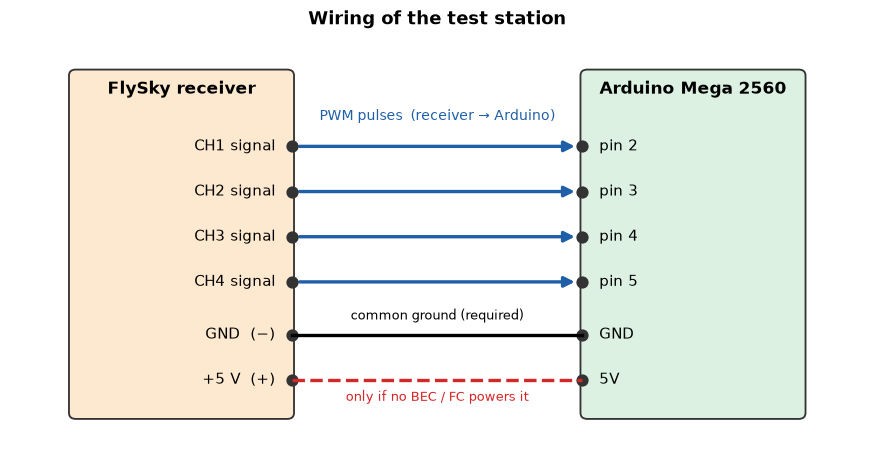

In [2]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(0, 10)
ax.set_ylim(0.2, 5.6)
ax.axis("off")
box(ax, 2.0, 2.8, 2.6, 4.6, "", C["rx"])
box(ax, 8.0, 2.8, 2.6, 4.6, "", C["arduino"])
ax.text(2.0, 4.8, "FlySky receiver", ha="center", fontweight="bold", fontsize=11)
ax.text(8.0, 4.8, "Arduino Mega 2560", ha="center", fontweight="bold", fontsize=11)

rows = [("CH1 signal", "pin 2", 4.1, C["blue"]), ("CH2 signal", "pin 3", 3.5, C["blue"]),
        ("CH3 signal", "pin 4", 2.9, C["blue"]), ("CH4 signal", "pin 5", 2.3, C["blue"]),
        ("GND  (−)", "GND", 1.6, "black"), ("+5 V  (+)", "5V", 1.0, "#d62728")]
for left, right, y, color in rows:
    ax.plot(3.3, y, "o", color="#333", ms=7)
    ax.plot(6.7, y, "o", color="#333", ms=7)
    ax.text(3.1, y, left, ha="right", va="center")
    ax.text(6.9, y, right, ha="left", va="center")
    if right == "5V":
        ax.plot([3.3, 6.7], [y, y], color=color, lw=2.2, ls="--")
        ax.text(5.0, y - 0.28, "only if no BEC / FC powers it", ha="center", fontsize=8.5, color=color)
    elif left.startswith("CH"):
        arrow(ax, 3.35, y, 6.65, y, color=color, lw=2.2)
    else:
        ax.plot([3.3, 6.7], [y, y], color=color, lw=2.2)
ax.text(5.0, 4.45, "PWM pulses  (receiver → Arduino)", ha="center", fontsize=9, color=C["blue"])
ax.text(5.0, 1.8, "common ground (required)", ha="center", fontsize=8.5)
ax.set_title("Wiring of the test station", fontsize=12, fontweight="bold")
fig.savefig("images/wiring_flysky.png", bbox_inches="tight")
plt.show()

## 5. The RC PWM signal

Each receiver channel outputs a pulse at a fixed rate (typically about **50 Hz**, one pulse every
**20 ms**). The **width** of the pulse carries the command:

| Stick position | Typical pulse width |
|---|---|
| minimum | ≈ 1000 µs |
| center | ≈ 1500 µs |
| maximum | ≈ 2000 µs |

Real values are slightly different, e.g. 995 / 1497 / 2006 µs — that is normal. The program accepts
**900–2100 µs** as an electrically reasonable RC pulse; anything else (or no pulse at all) is counted as
a **lost sample**.

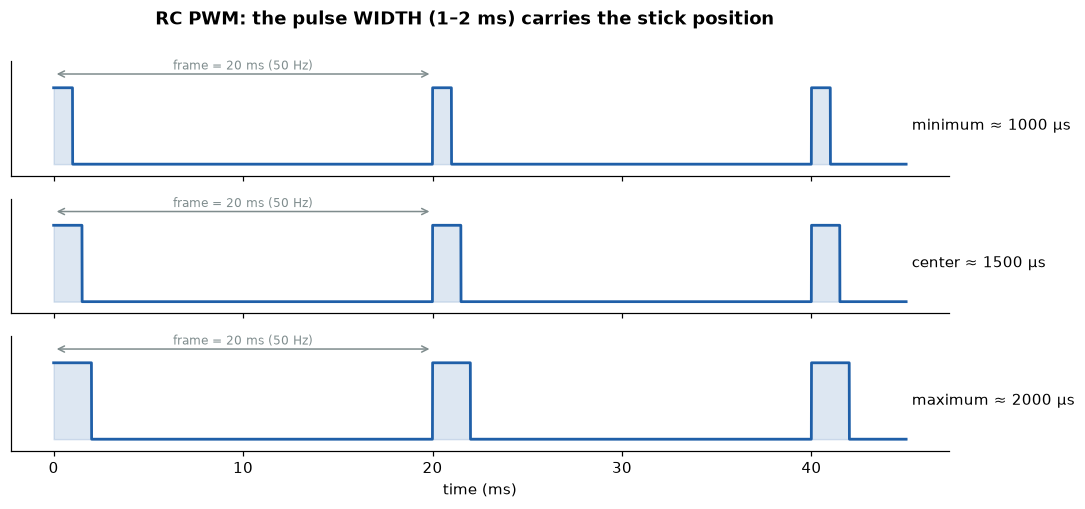

In [3]:
frame_ms = 20.0
t = np.linspace(0, 45, 9001)

fig, axes = plt.subplots(3, 1, figsize=(11, 4.6), sharex=True)
for ax, (width_us, label) in zip(axes, [(1000, "minimum ≈ 1000 µs"), (1500, "center ≈ 1500 µs"), (2000, "maximum ≈ 2000 µs")]):
    level = ((t % frame_ms) < width_us / 1000).astype(float)
    ax.plot(t, level, color=C["blue"], lw=1.8)
    ax.fill_between(t, 0, level, color=C["blue"], alpha=0.15)
    ax.set_yticks([])
    ax.set_ylim(-0.15, 1.35)
    ax.text(45.3, 0.5, label, va="center", fontsize=9.5)
    ax.annotate("", xy=(20, 1.18), xytext=(0, 1.18), arrowprops=dict(arrowstyle="<->", color=C["grey"]))
    ax.text(10, 1.2, "frame = 20 ms (50 Hz)", ha="center", va="bottom", fontsize=8, color=C["grey"])
axes[-1].set_xlabel("time (ms)")
fig.suptitle("RC PWM: the pulse WIDTH (1–2 ms) carries the stick position", fontweight="bold")
fig.savefig("images/rc_pwm_signal.png", bbox_inches="tight")
plt.show()

## 6. How the Arduino measures PWM (`pulseIn`) and the timing budget

```cpp
// Returns the length of one HIGH pulse in microseconds,
// or 0 if no pulse arrived before PWM_TIMEOUT.
unsigned long readPWM(byte pin)
{
  return pulseIn(pin, HIGH, PWM_TIMEOUT);
}
```

`pulseIn(pin, HIGH, timeout)` waits for the pin to go HIGH, measures how long it stays HIGH and returns
that time in µs — or **0** if no complete pulse arrived before the timeout.

**Choosing the timeout.** If `pulseIn()` is called while a pulse is already HIGH, it first waits for that
pulse to end, then for the next rising edge, and then measures:

$$ t_\text{worst} \approx \underbrace{2\,\text{ms}}_{\text{current pulse}} + \underbrace{18\,\text{ms}}_{\text{gap}} + \underbrace{2\,\text{ms}}_{\text{next pulse}} \approx 22\,\text{ms} $$

The first version used 25 ms (only 3 ms margin); the final version uses **30 ms**. A receiver that
outputs pulses less often than every ~27 ms would need a longer timeout.

**Samples per test.** The four channels are read one after the other and each read waits for about one
frame, so one pass over all channels takes ≈ 4 × 20 ms = 80 ms:

In [4]:
frame_ms, channels = 20.0, 4
pass_ms = channels * frame_ms

phases = [("TEST 1 connection", 3.0), ("TEST 2 neutral", 3.0), ("TESTS 3–6 each end point", 2.0),
          ("TEST 7 stability", 8.0), ("TEST 8 each 2-s window", 2.0), ("TEST 8 range (total)", 20.0),
          ("TEST 9 failsafe, TX off", 5.0), ("TEST 10 recovery", 4.0)]

print(f"one pass over {channels} channels ≈ {pass_ms:.0f} ms  →  {1000 / pass_ms:.1f} samples per second per channel\n")
print(f"{'phase':28s} {'duration':>9s} {'samples / channel':>18s}")
for name, seconds in phases:
    print(f"{name:28s} {seconds:>7.0f} s {seconds * 1000 / pass_ms:>15.0f}")

one pass over 4 channels ≈ 80 ms  →  12.5 samples per second per channel

phase                         duration  samples / channel
TEST 1 connection                  3 s              38
TEST 2 neutral                     3 s              38
TESTS 3–6 each end point           2 s              25
TEST 7 stability                   8 s             100
TEST 8 each 2-s window             2 s              25
TEST 8 range (total)              20 s             250
TEST 9 failsafe, TX off            5 s              62
TEST 10 recovery                   4 s              50


The simulation of the real sketch (section 17) gives the same numbers: 25 samples per channel in 2 s,
38 in 3 s and 250 in the 20 s range test.

**Measurement resolution.** `pulseIn()` counts processor loop cycles. The Arduino's own timer interrupt
(for `millis()`) occasionally pauses that loop for a few microseconds, so a perfectly stable signal can show
a jitter of a few µs. The stability limits (≤ 8 µs = excellent) take this into account.

## 7. The test sequence

| Test | Operator action | Measured | Points |
|---|---|---|---|
| — | type a unit ID (or just ENTER) | — | — |
| 1 | transmitter ON, receiver bound | PWM availability of all channels (3 s) | 10 |
| 2 | roll / pitch / yaw centered, throttle minimum | center values (3 s) | 15 |
| 3A / 3B | roll fully left / right, hold | end points, **roll travel** | 10 |
| 4A / 4B | pitch fully down / up, hold | **pitch travel** | 10 |
| 5A / 5B | throttle minimum / maximum | **throttle travel** | 10 |
| 6A / 6B | yaw fully left / right, hold | **yaw travel** | 10 |
| 7 | do not touch the controls | jitter SD of every channel (8 s) | 15 |
| 8 | walk to the test distance (15 s countdown), move roll continuously | availability, roll span, **live windows** (20 s) | 20 |
| 9 | throttle at half → transmitter OFF | failsafe behavior of every channel | not scored |
| 10 | throttle low, transmitter ON, move roll | recovery of **live** commands (4 s) | pass / fail |

When the operator must move a control, the program asks them to move it, **hold** it and press ENTER; it then
measures automatically. After the report it asks for the next unit, so many units can be tested
without pressing RESET.

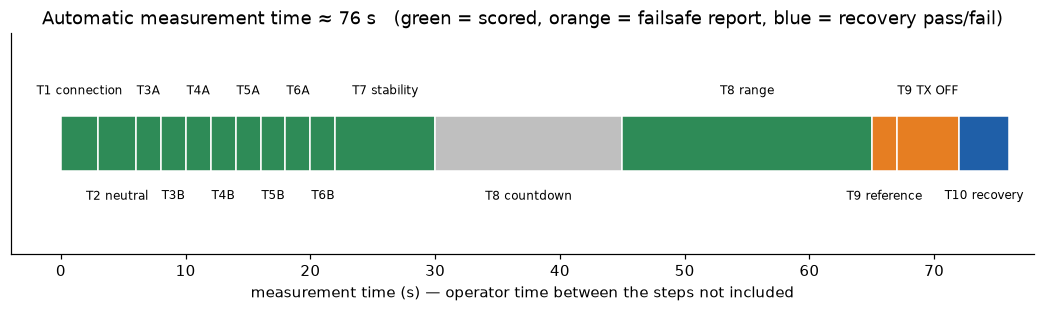

In [5]:
sequence = [("unit ID", 0, "#dddddd"), ("T1 connection", 3, C["green"]), ("T2 neutral", 3, C["green"])]
sequence += [(f"T{3 + i // 2}{'AB'[i % 2]}", 2, C["green"]) for i in range(8)]
sequence += [("T7 stability", 8, C["green"]), ("T8 countdown", 15, "#bfbfbf"), ("T8 range", 20, C["green"]),
             ("T9 reference", 2, C["orange"]), ("T9 TX OFF", 5, C["orange"]), ("T10 recovery", 4, C["blue"])]

fig, ax = plt.subplots(figsize=(12, 2.6))
t = 0
for i, (name, duration, color) in enumerate(sequence):
    if duration:
        ax.barh(0, duration, left=t, color=color, edgecolor="white", height=0.5)
        ax.text(t + duration / 2, 0.42 if i % 2 else -0.42, name, ha="center",
                va="bottom" if i % 2 else "top", fontsize=8, rotation=0)
    t += duration
ax.set_yticks([])
ax.set_ylim(-1, 1)
ax.set_xlim(-4, t + 2)
ax.set_xlabel("measurement time (s) — operator time between the steps not included")
ax.set_title(f"Automatic measurement time ≈ {t} s   (green = scored, orange = failsafe report, blue = recovery pass/fail)")
fig.savefig("images/test_sequence.png", bbox_inches="tight")
plt.show()

## 8. Statistics: availability, mean and standard deviation

For every channel and every measurement the program keeps:

* `validSamples`, `invalidSamples` → **availability** $= 100\,\% \cdot \dfrac{\text{valid}}{\text{valid} + \text{lost}}$
* `minPWM`, `maxPWM` → **span** $= \max - \min$
* **mean** $\bar{x} = \frac{1}{n}\sum x_i$ and **standard deviation** $\sigma = \sqrt{\frac{1}{n}\sum (x_i - \bar{x})^2}$
  (the jitter)

### Why Welford's algorithm?

On the Arduino Mega `double` is only a **32-bit float** (about 7 significant digits). The first version
used the textbook formula $\sigma^2 = \overline{x^2} - \bar{x}^2$, which subtracts two nearly equal numbers
of about 2 250 000. The final version uses **Welford's online algorithm**, which only accumulates small
deviations from the running mean:

```cpp
// Adds one reading to the statistics of a channel.
//
// The mean and the standard deviation are updated with Welford's
// online algorithm. On the Arduino Mega "double" is only a 32-bit
// float (about 7 significant digits). The textbook formula
//     variance = sum(x^2)/n - mean^2
// subtracts two almost equal numbers of about 2 250 000 and can lose
// 1-3 us of accuracy on long measurements. Welford's method only adds
// small deviations from the running mean and stays accurate.
void addSample(ChannelStats &s, unsigned long pwm)
{
  if (!validPWM(pwm))
  {
    s.invalidSamples++;
    return;
  }

  s.validSamples++;

  if (pwm < s.minPWM)
    s.minPWM = pwm;

  if (pwm > s.maxPWM)
    s.maxPWM = pwm;

  float x = (float)pwm;
  float delta = x - s.average;

  s.average += delta / s.validSamples;
  s.m2 += delta * (x - s.average);
}
```

The cell below reproduces both methods with 32-bit floats (`numpy.float32`) and compares them with the
exact result:

n =    25 samples:  worst error  textbook =  0.98 µs   Welford = 0.0000 µs


n =    50 samples:  worst error  textbook =  0.52 µs   Welford = 0.0000 µs
n =   100 samples:  worst error  textbook =  1.01 µs   Welford = 0.0001 µs
n =   250 samples:  worst error  textbook =  1.02 µs   Welford = 0.0000 µs
n =   500 samples:  worst error  textbook =  1.13 µs   Welford = 0.0000 µs


n =  1000 samples:  worst error  textbook =  2.92 µs   Welford = 0.0001 µs


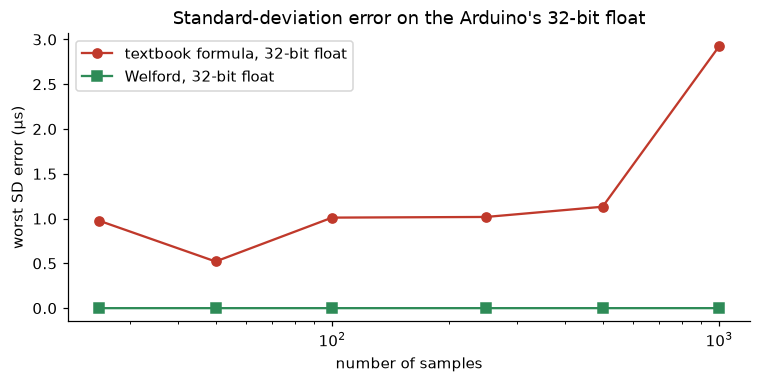

In [6]:
rng = np.random.default_rng(1)


def naive_float32(x):
    s = ss = np.float32(0)
    for v in x.astype(np.float32):
        s = np.float32(s + v)
        ss = np.float32(ss + v * v)
    n = np.float32(len(x))
    mean = np.float32(s / n)
    return float(np.sqrt(max(np.float32(ss / n - mean * mean), 0)))


def welford_float32(x):
    mean = m2 = np.float32(0)
    for n, v in enumerate(x.astype(np.float32), start=1):
        delta = np.float32(v - mean)
        mean = np.float32(mean + delta / np.float32(n))
        m2 = np.float32(m2 + delta * np.float32(v - mean))
    return float(np.sqrt(m2 / np.float32(len(x))))


sizes = [25, 50, 100, 250, 500, 1000]
worst_naive, worst_welford = [], []
for n in sizes:
    e_naive = e_welford = 0.0
    for trial in range(60):
        x = np.round(rng.normal(1900, 1.0, n))          # stable signal near 1900 µs, SD ≈ 1 µs
        exact = x.std()
        e_naive = max(e_naive, abs(naive_float32(x) - exact))
        e_welford = max(e_welford, abs(welford_float32(x) - exact))
    worst_naive.append(e_naive)
    worst_welford.append(e_welford)
    print(f"n = {n:5d} samples:  worst error  textbook = {e_naive:5.2f} µs   Welford = {e_welford:.4f} µs")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(sizes, worst_naive, "o-", color=C["red"], label="textbook formula, 32-bit float")
ax.plot(sizes, worst_welford, "s-", color=C["green"], label="Welford, 32-bit float")
ax.set_xscale("log")
ax.set_xlabel("number of samples")
ax.set_ylabel("worst SD error (µs)")
ax.set_title("Standard-deviation error on the Arduino's 32-bit float")
ax.legend()
fig.savefig("images/float32_variance_error.png", bbox_inches="tight")
plt.show()

The textbook formula can be off by 1–3 µs on long measurements. That is small compared with the stability
limits (8 / 16 / 30 µs), so this was a **precision improvement rather than a critical bug** — but Welford
is exact to better than 0.01 µs at no extra cost.

## 9. The scoring system

| Category | Points | Rule |
|---|---|---|
| Connection quality | 10 | availability ≥ 98 % → 10, ≥ 90 % → 7, else 0 |
| Neutral positions | 15 | roll, pitch, yaw each 5 points if 1400–1600 µs |
| Roll travel | 10 | travel score (below) |
| Pitch travel | 10 | travel score |
| Throttle travel | 10 | travel score |
| Yaw travel | 10 | travel score |
| PWM stability | 15 | mean SD ≤ 8 µs → 15, ≤ 16 → 12, ≤ 30 → 7, else 0; **0 if a channel has < 90 % valid pulses** |
| Distance response | 20 | see section 10 |
| **Total** | **100** | |

**Travel score:** ≥ 900 µs → 10, ≥ 800 → 9, ≥ 700 → 7, ≥ 600 → 5, ≥ 400 → 2, else 0.
A travel is only computed when **both** end points were measured — a missing end point gives 0 points.

**System condition**

| Score | Condition |
|---|---|
| 90–100 | EXCELLENT |
| 80–89 | GOOD |
| 65–79 | MARGINAL / INSPECTION REQUIRED |
| below 65 | FAIL / DO NOT USE FOR FLIGHT |

EXCELLENT and GOOD additionally require that **the link recovered** (TEST 10) and that **no category
scored 0 points**; otherwise the condition is at most MARGINAL. These limits are engineering diagnostic
limits of this procedure, not official FlySky acceptance limits.

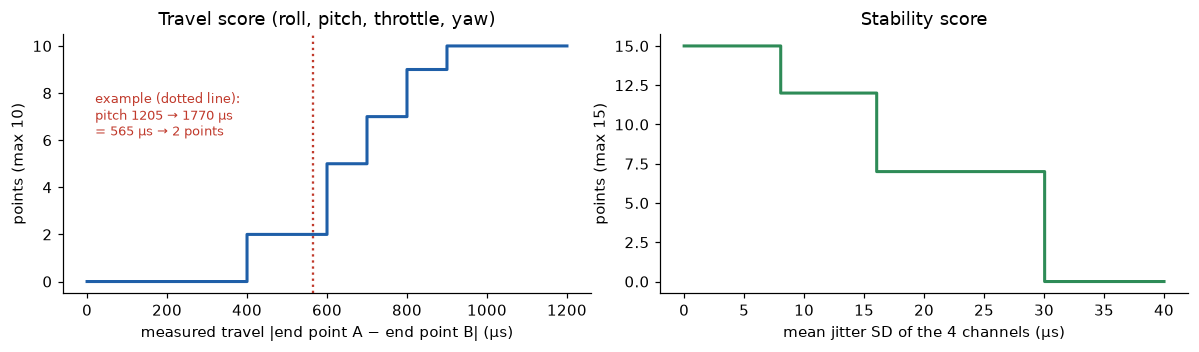

Example from the documentation: pitch 1205 → 1770 µs: 565 µs → 2 points


In [7]:
def travel_score(travel):
    for limit, points in [(900, 10), (800, 9), (700, 7), (600, 5), (400, 2)]:
        if travel >= limit:
            return points
    return 0


def stability_score(sd):
    for limit, points in [(8, 15), (16, 12), (30, 7)]:
        if sd <= limit:
            return points
    return 0


fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.3))
travel = np.arange(0, 1201)
a1.step(travel, [travel_score(v) for v in travel], where="post", color=C["blue"], lw=2)
a1.set_xlabel("measured travel |end point A − end point B| (µs)")
a1.set_ylabel("points (max 10)")
a1.set_title("Travel score (roll, pitch, throttle, yaw)")
a1.axvline(565, color=C["red"], ls=":")
a1.text(20, 6.2, "example (dotted line):\npitch 1205 → 1770 µs\n= 565 µs → 2 points", fontsize=8.5, color=C["red"])

sd = np.linspace(0, 40, 801)
a2.step(sd, [stability_score(v) for v in sd], where="post", color=C["green"], lw=2)
a2.set_xlabel("mean jitter SD of the 4 channels (µs)")
a2.set_ylabel("points (max 15)")
a2.set_title("Stability score")
fig.tight_layout()
fig.savefig("images/scoring_curves.png", bbox_inches="tight")
plt.show()

print("Example from the documentation: pitch 1205 → 1770 µs:", 1770 - 1205, "µs →", travel_score(565), "points")

## 10. TEST 8 — distance / live-link test with time windows

Merely seeing PWM pulses is **not** enough: many receivers keep outputting pulses after the RF link is lost
(hold-last-value or programmed failsafe values). **PWM present does not always mean RF link present.**
That is why the operator continuously moves the ROLL stick during the test — a live link produces a
large, changing CH1 signal.

**Weakness of the first version:** it computed one `max − min` span over the whole 20 s. If the link was
lost after 8 s, the movement recorded in the first 8 s still produced a full ~1000 µs span and an
*EXCELLENT* score.

**Final version:** the 20 s are divided into **ten 2-s windows**. A window is **LIVE** only if the ROLL output
moved by at least **300 µs** inside that window.

```cpp
  for (byte w = 0; w < rangeTotalWindows; w++)
  {
    unsigned int windowMin = 65535;
    unsigned int windowMax = 0;

    unsigned long windowStart = millis();

    while (millis() - windowStart < RANGE_WINDOW_MS)
    {
      readAllChannels(stats, readings);

      unsigned int roll = readings[CH_ROLL];

      if (roll > 0)
      {
        if (roll < windowMin)
          windowMin = roll;

        if (roll > windowMax)
          windowMax = roll;
      }
    }

    unsigned int windowSpan = 0;

    if (windowMax > windowMin)
      windowSpan = windowMax - windowMin;

    bool live = windowSpan >= LIVE_WINDOW_MIN_SPAN;

    if (live)
      rangeLiveWindows++;

    ...   // print "Window n/10 : ROLL span = ... us -> LIVE"
  }
```

| Range score | availability | overall roll span | live windows |
|---|---|---|---|
| 20 — EXCELLENT | ≥ 98 % | ≥ 800 µs | ≥ 90 % |
| 16 — GOOD | ≥ 95 % | ≥ 650 µs | ≥ 80 % |
| 10 — MARGINAL | ≥ 90 % | ≥ 400 µs | ≥ 60 % |
| 0 — FAIL | otherwise | | |

The simulation below reproduces the measurement (one CH1 sample every 80 ms) for a healthy link and for a
link that is lost after 8 s while the receiver **holds** its last value:

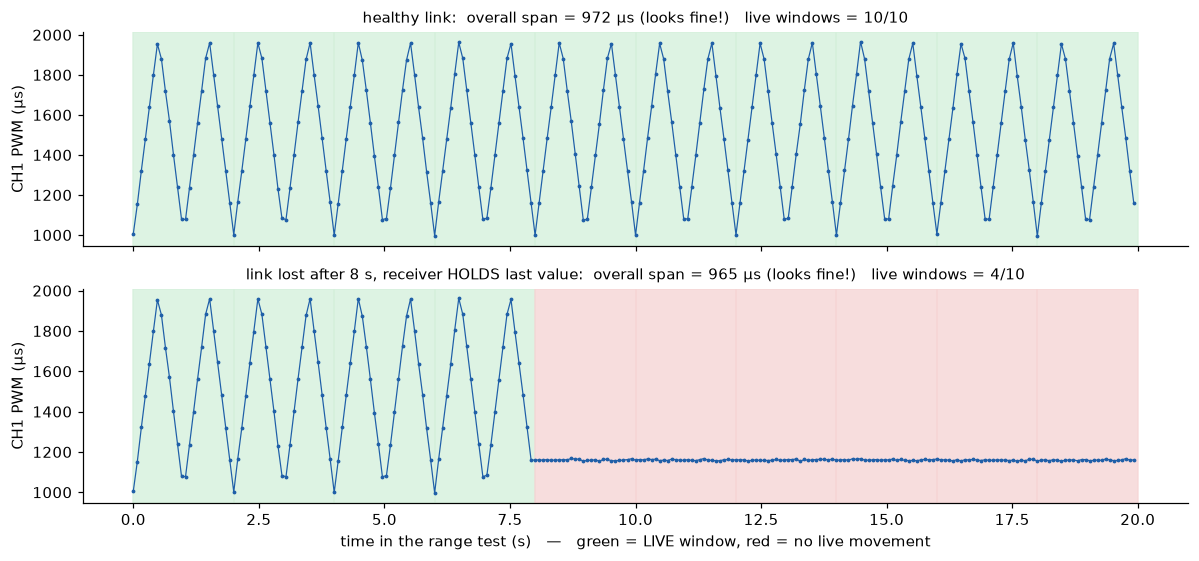

In [8]:
def simulate_roll(link_lost_at=None, duration=20.0, sample_period=0.08, seed=3):
    rng = np.random.default_rng(seed)
    times = np.arange(0, duration, sample_period)
    values, last = [], 1500.0
    for t in times:
        if link_lost_at is None or t < link_lost_at:
            phase = t % 1.0                                     # operator: 1 movement per second
            position = -1 + 4 * phase if phase < 0.5 else 3 - 4 * phase
            last = 1500 + 500 * position
        values.append(last + rng.normal(0, 3))                  # hold last value after link loss
    return times, np.array(values)


def analyse(times, values, window=2.0, min_span=300):
    live = []
    for start in np.arange(0, 20, window):
        inside = values[(times >= start) & (times < start + window)]
        live.append(inside.max() - inside.min() >= min_span)
    return values.max() - values.min(), live


fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)
for ax, (title, lost) in zip(axes, [("healthy link", None), ("link lost after 8 s, receiver HOLDS last value", 8.0)]):
    times, values = simulate_roll(lost)
    span, live = analyse(times, values)
    for w, ok in enumerate(live):
        ax.axvspan(2 * w, 2 * w + 2, color="#d5f0dc" if ok else "#f6d5d5", alpha=0.8)
    ax.plot(times, values, ".-", color=C["blue"], ms=3, lw=0.8)
    ax.set_ylabel("CH1 PWM (µs)")
    ax.set_title(f"{title}:  overall span = {span:.0f} µs (looks fine!)   live windows = {sum(live)}/10", fontsize=10)
axes[-1].set_xlabel("time in the range test (s)   —   green = LIVE window, red = no live movement")
fig.tight_layout()
fig.savefig("images/range_live_windows.png", bbox_inches="tight")
plt.show()

In both cases the overall span is about 1000 µs, but only the window analysis reveals the lost link
(4/10 live windows → **range score 0**, plus a note that the receiver was probably sending
failsafe/hold values). Output of the real sketch during a healthy range test (host simulation):

```text
*** START MOVING ROLL LEFT/RIGHT NOW ***

Window 1/10 : ROLL span = 968 us -> LIVE
Window 2/10 : ROLL span = 963 us -> LIVE
Window 3/10 : ROLL span = 958 us -> LIVE
Window 4/10 : ROLL span = 949 us -> LIVE
Window 5/10 : ROLL span = 957 us -> LIVE
Window 6/10 : ROLL span = 965 us -> LIVE
Window 7/10 : ROLL span = 958 us -> LIVE
Window 8/10 : ROLL span = 957 us -> LIVE
Window 9/10 : ROLL span = 966 us -> LIVE
Window 10/10 : ROLL span = 969 us -> LIVE

*** RANGE TEST COMPLETE ***

ROLL / CH1     | AVG = 1499.2 us | MIN = 995 | MAX = 1969 | SD = 289.26 us | Valid = 250 | Lost = 0
PITCH / CH2    | AVG = 1500.3 us | MIN = 1492 | MAX = 1509 | SD = 3.25 us | Valid = 250 | Lost = 0
THROTTLE / CH3 | AVG = 999.7 us | MIN = 990 | MAX = 1009 | SD = 3.14 us | Valid = 250 | Lost = 0
YAW / CH4      | AVG = 1499.8 us | MIN = 1493 | MAX = 1508 | SD = 2.96 us | Valid = 250 | Lost = 0

PWM availability at distance = 100.0%
Observed ROLL movement span   = 974 us
Live-response windows         = 10/10 (100%)
RANGE RESPONSE: EXCELLENT
```

## 11. TEST 9 — failsafe test

When the transmitter is switched off, a receiver can

* **stop** the PWM output completely,
* **hold** the last received values, or
* output **programmed failsafe values**.

Which behavior is correct depends on the application (a flight controller usually detects missing
pulses; a direct ESC connection needs a low-throttle failsafe). The test therefore **reports** the observed
behavior and does not include it in the score — but it adds one important **safety check on the throttle**.

**Why the throttle is raised to about half first (STEP 1):** with the throttle at minimum, "hold last value"
and "failsafe = throttle low" look identical. At half throttle they are clearly different:

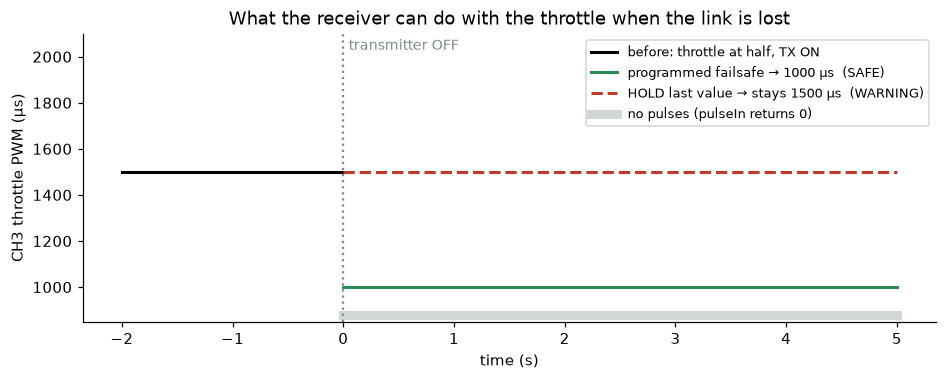

In [9]:
t = np.linspace(-2, 5, 701)
fig, ax = plt.subplots(figsize=(10, 3.4))
before = 1500
ax.plot(t[t < 0], np.full((t < 0).sum(), before), color="black", lw=2, label="before: throttle at half, TX ON")
ax.plot(t[t >= 0], np.full((t >= 0).sum(), 1000), color=C["green"], lw=2, label="programmed failsafe → 1000 µs  (SAFE)")
ax.plot(t[t >= 0], np.full((t >= 0).sum(), 1500), color=C["red"], lw=2, ls="--", label="HOLD last value → stays 1500 µs  (WARNING)")
ax.plot([0, 5], [880, 880], color=C["grey"], lw=6, alpha=0.35, label="no pulses (pulseIn returns 0)")
ax.axvline(0, color=C["grey"], ls=":")
ax.text(0.05, 2030, "transmitter OFF", color=C["grey"], fontsize=9)
ax.set_ylim(850, 2100)
ax.set_xlabel("time (s)")
ax.set_ylabel("CH3 throttle PWM (µs)")
ax.set_title("What the receiver can do with the throttle when the link is lost")
ax.legend(loc="upper right", fontsize=8.5)
fig.savefig("images/failsafe_behavior.png", bbox_inches="tight")
plt.show()

The throttle value after TX OFF is converted into a position between the measured end points:

$$ \text{position} = \frac{\text{PWM}_\text{failsafe} - \text{throttleMin}}{\text{throttleMax} - \text{throttleMin}} $$

(0 % = minimum, 100 % = maximum; this also works if the throttle channel is reversed). A position of
**5 % or less** is judged **SAFE**. A higher value prints a prominent warning, because motors could keep
running after a link loss.

```cpp
    // 0.0 = throttle minimum, 1.0 = throttle maximum.
    // Works even if the throttle channel is reversed.
    float position =
      (thr.average - throttleMin) / (throttleMax - throttleMin);

    Serial.print(thr.average, 0);
    Serial.print(F(" us = "));
    Serial.print(lround(position * 100.0));
    Serial.println(F("% throttle"));

    if (position <= THROTTLE_LOW_FRACTION)
    {
      failsafeResult = FAILSAFE_THROTTLE_LOW;

      Serial.println(F("SAFE: throttle goes to MINIMUM when the link is lost."));
    }
    else
    {
      failsafeResult = FAILSAFE_THROTTLE_NOT_LOW;

      Serial.println(F("*** WARNING: throttle does NOT go to minimum when ***"));
      Serial.println(F("*** the link is lost. Motors could keep running.  ***"));
      Serial.println(F("Set the failsafe in the transmitter (throttle low)"));
      Serial.println(F("before using this system in an aircraft."));
    }
```

Example output of the sketch (host simulation, failsafe programmed to throttle low):

```text
Observed behavior per channel:
ROLL / CH1     : UNCHANGED (1500 us)
PITCH / CH2    : UNCHANGED (1500 us)
THROTTLE / CH3 : CHANGED TO 1000 us (failsafe value)
YAW / CH4      : UNCHANGED (1500 us)

Observed failsafe behavior:
RECEIVER CONTINUED PWM OUTPUT.

This may indicate:
- programmed failsafe values
- hold-last-position behavior
- another configured failsafe mode

THROTTLE on signal loss: 1000 us = 0% throttle
SAFE: throttle goes to MINIMUM when the link is lost.
```

## 12. TEST 10 — link recovery

The first version passed the recovery test whenever PWM pulses were present (availability ≥ 95 %). A receiver
that outputs failsafe values would therefore **pass even if the transmitter never reconnected**.

The final version asks the operator to **move the ROLL stick continuously** during the 4-s measurement and
requires both

* availability ≥ 95 %, **and**
* a ROLL movement span ≥ 400 µs (live commands are back).

If pulses are present but ROLL does not follow the stick, the sketch prints
*"PWM is present but ROLL does not follow the stick: the receiver may still be in failsafe."*
A failed recovery limits the system condition to MARGINAL at best.

## 13. How to run the test

1. Wire the receiver as in section 4. **Remove all propellers.**
2. Open `flysky_health_test/flysky_health_test.ino` in the Arduino IDE.
3. *Tools → Board → Arduino Mega or Mega 2560*, select the port, **Upload**.
4. Open the **Serial Monitor**: **115200 baud**, line ending **Newline**.
5. Type a unit ID (e.g. `TX-001`) and press ENTER — or just press ENTER.
6. Follow the instructions. When the program asks you to move a control: move it, **hold it**, then press
   ENTER; the Arduino measures automatically.

Example prompt:

```text
================================================
TEST 3A - ROLL LEFT
================================================
Move ROLL fully LEFT and HOLD it.
(Mode 2: RIGHT stick to the LEFT)

>>> Press ENTER when ready.
```

The stick hints are for a **Mode 2** transmitter (FS-i6X default): right stick = roll + pitch,
left stick = throttle + yaw.

**Distance test:** after ENTER you have 15 s to carry the transmitter to the test distance; then the
20-s measurement starts. Start moving ROLL fully left ↔ right (about once per second) as soon as you are
in position and keep moving until at least 40 s after pressing ENTER.

## 14. The final report

Example of a healthy system (produced by the host simulation of the real sketch):

```text
################################################
#                                              #
#         FINAL RC SYSTEM HEALTH REPORT        #
#                                              #
################################################

Unit ID                  : UNIT-01
Initial PWM availability : 100.0%  (PASS)

----------- MEASURED ENDPOINTS ----------------
ROLL LEFT        : 1000.9 us
ROLL RIGHT       : 1999.8 us
ROLL TRAVEL      : 998.9 us

PITCH DOWN       : 999.5 us
PITCH UP         : 1999.6 us
PITCH TRAVEL     : 1000.1 us

THROTTLE MIN     : 1000.4 us
THROTTLE MAX     : 2000.3 us
THROTTLE TRAVEL  : 999.9 us

YAW LEFT         : 1000.0 us
YAW RIGHT        : 1999.6 us
YAW TRAVEL       : 999.7 us

--------------- STABILITY --------------------
ROLL / CH1      jitter SD = 2.75 us
PITCH / CH2     jitter SD = 2.89 us
THROTTLE / CH3  jitter SD = 3.10 us
YAW / CH4       jitter SD = 3.05 us

---------------- RANGE -----------------------
Range PWM availability : 100.0%
Range ROLL span        : 974 us
Live-response windows  : 10/10

------------ FAILSAFE / RECOVERY -------------
Throttle on signal loss : THROTTLE LOW (SAFE)
Link recovery           : PASS

---------------- SCORES ----------------------
Connection        : 10 / 10
Neutral controls  : 15 / 15
Roll travel       : 10 / 10
Pitch travel      : 10 / 10
Throttle travel   : 10 / 10
Yaw travel        : 10 / 10
Signal stability  : 15 / 15
Distance response : 20 / 20

==============================================
FINAL DIAGNOSTIC HEALTH SCORE = 100 / 100
==============================================

SYSTEM CONDITION:
*** EXCELLENT ***

All major functional tests passed.

IMPORTANT:
This is a functional diagnostic score.
It is NOT an official FlySky factory
certification or RF compliance measurement.

CSV_HEADER,unit_id,score,condition,connection,neutral,roll,pitch,throttle,yaw,stability,range,initial_availability,roll_travel,pitch_travel,throttle_travel,yaw_travel,avg_jitter_sd,range_availability,range_span,live_windows,failsafe_throttle,recovery
CSV_RESULT,UNIT-01,100,EXCELLENT,10,15,10,10,10,10,15,20,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE LOW (SAFE),PASS

```

**Interpretation**

* **Endpoints / travel** — around 1000 µs of travel per stick is the normal full range. A reduced travel
  (e.g. pitch 1205 → 1770 µs = 565 µs) points to transmitter end-point settings, calibration, a worn stick
  potentiometer, a wrong channel setup or receiver configuration.
* **Stability** — with the sticks untouched, values such as 1499 / 1502 / 1498 / 1501 µs are a small
  variation (SD ≈ 1–5 µs). Values such as 1450 / 1530 / 1480 / 1550 µs are a large variation.
* **Range** — availability and live windows must stay high at the test distance.
* **Failsafe / recovery** — must be *SAFE* and *PASS* before the system is used in an aircraft.

## 15. Testing many units (CSV line)

At the end of each report the sketch prints a machine-readable line, for example:

```text
CSV_HEADER,unit_id,score,condition,connection,neutral,roll,pitch,throttle,yaw,stability,range,initial_availability,roll_travel,pitch_travel,throttle_travel,yaw_travel,avg_jitter_sd,range_availability,range_span,live_windows,failsafe_throttle,recovery
CSV_RESULT,UNIT-01,100,EXCELLENT,10,15,10,10,10,10,15,20,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE LOW (SAFE),PASS
```

Copy the `CSV_RESULT` lines of all units into a text file (or a spreadsheet) to compare them. For meaningful
comparisons test every unit under the **same conditions**: receiver and antenna orientation, receiver
voltage, transmitter batteries, Arduino hardware, distance, environment and test duration — for example
*Station A* bench test at 1 m, *Station B* short range at 10 m, *Station C* a fixed long distance.

The cell below analyses such a log. The rows are the **simulated units** of section 17 (not real hardware):

unit             score  condition                        failsafe                     recovery
SIM-healthy        100  EXCELLENT                        THROTTLE LOW (SAFE)          PASS
SIM-fs-hold        100  EXCELLENT                        THROTTLE NOT LOW (WARNING)   PASS
SIM-short-pitch     92  EXCELLENT                        THROTTLE LOW (SAFE)          PASS
SIM-ch2-dropout     90  MARGINAL / INSPECTION REQUIRED   THROTTLE LOW (SAFE)          PASS
SIM-link-lost       80  MARGINAL / INSPECTION REQUIRED   THROTTLE NOT LOW (WARNING)   PASS
SIM-no-recovery    100  MARGINAL / INSPECTION REQUIRED   THROTTLE LOW (SAFE)          FAIL
SIM-ch4-open        40  FAIL / DO NOT USE FOR FLIGHT     THROTTLE LOW (SAFE)          FAIL
SIM-noisy           97  EXCELLENT                        THROTTLE LOW (SAFE)          PASS


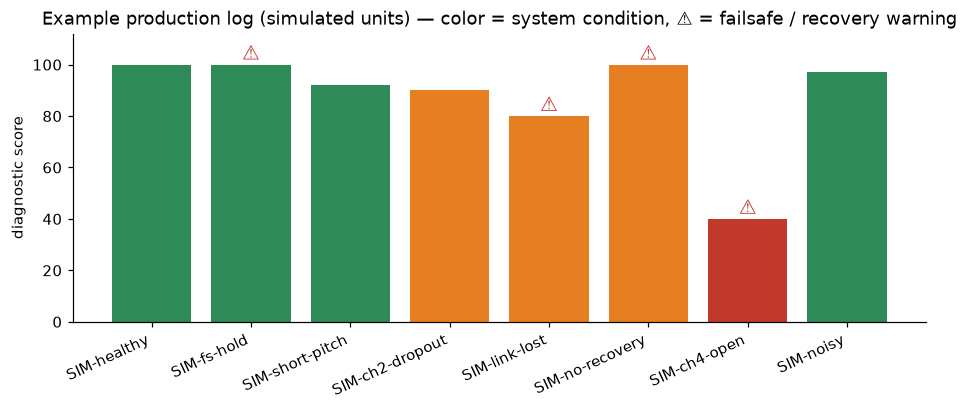

In [10]:
log = '''
CSV_RESULT,SIM-healthy,100,EXCELLENT,10,15,10,10,10,10,15,20,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE LOW (SAFE),PASS
CSV_RESULT,SIM-fs-hold,100,EXCELLENT,10,15,10,10,10,10,15,20,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE NOT LOW (WARNING),PASS
CSV_RESULT,SIM-short-pitch,92,EXCELLENT,10,15,10,2,10,10,15,20,100.0,998.9,565.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE LOW (SAFE),PASS
CSV_RESULT,SIM-ch2-dropout,90,MARGINAL / INSPECTION REQUIRED,10,15,10,0,10,10,15,20,100.0,998.9,,999.5,999.1,2.9,100.0,968,10/10,THROTTLE LOW (SAFE),PASS
CSV_RESULT,SIM-link-lost,80,MARGINAL / INSPECTION REQUIRED,10,15,10,10,10,10,15,0,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,968,4/10,THROTTLE NOT LOW (WARNING),PASS
CSV_RESULT,SIM-no-recovery,100,MARGINAL / INSPECTION REQUIRED,10,15,10,10,10,10,15,20,100.0,998.9,1000.1,999.9,999.7,2.9,100.0,974,10/10,THROTTLE LOW (SAFE),FAIL
CSV_RESULT,SIM-ch4-open,40,FAIL / DO NOT USE FOR FLIGHT,0,10,10,10,10,0,0,0,75.0,1001.1,1000.3,1000.4,,,75.0,998,10/10,THROTTLE LOW (SAFE),FAIL
CSV_RESULT,SIM-noisy,97,EXCELLENT,10,15,10,10,10,10,12,20,100.0,996.0,1000.2,999.4,998.5,11.8,100.0,1016,10/10,THROTTLE LOW (SAFE),PASS
'''
header = ("unit_id,score,condition,connection,neutral,roll,pitch,throttle,yaw,stability,range,initial_availability,"
          "roll_travel,pitch_travel,throttle_travel,yaw_travel,avg_jitter_sd,range_availability,range_span,"
          "live_windows,failsafe_throttle,recovery").split(",")

units = [dict(zip(header, line.split(",")[1:])) for line in log.strip().splitlines() if line.startswith("CSV_RESULT")]

print(f"{'unit':16s} {'score':>5s}  {'condition':32s} {'failsafe':28s} recovery")
for u in units:
    print(f"{u['unit_id']:16s} {u['score']:>5s}  {u['condition']:32s} {u['failsafe_throttle']:28s} {u['recovery']}")

colors = {"EXCELLENT": C["green"], "GOOD": "#8bc34a", "MARGINAL / INSPECTION REQUIRED": C["orange"],
          "FAIL / DO NOT USE FOR FLIGHT": C["red"]}
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar([u["unit_id"] for u in units], [int(u["score"]) for u in units],
       color=[colors[u["condition"]] for u in units])
for x, u in enumerate(units):
    if u["failsafe_throttle"].startswith("THROTTLE NOT LOW") or u["recovery"] == "FAIL":
        ax.text(x, int(u["score"]) + 2, "⚠", ha="center", fontsize=13, color=C["red"])
ax.set_ylim(0, 112)
ax.set_ylabel("diagnostic score")
ax.set_title("Example production log (simulated units) — color = system condition, ⚠ = failsafe / recovery warning")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
fig.savefig("images/example_units.png", bbox_inches="tight")
plt.show()

## 16. Code review: what was checked and fixed

The first version of the sketch was reviewed line by line, compiled for the Mega and executed in a host
simulation (section 17). The complete list is in [`CODE_REVIEW.md`](../CODE_REVIEW.md).

| # | Finding in the first version | Effect | Fix |
|---|---|---|---|
| 1 | A missing signal during an end-point capture returned an average of **0 µs**; the travel was then computed against 0 | a disconnected channel could get **10/10 travel points** (simulated: 100/100 EXCELLENT with CH2 lost during *PITCH DOWN*) | the capture returns *not measured* (`NAN`), travel score 0, clear message |
| 2 | Stability test: a channel without signal has SD = 0 and looked perfectly stable | disconnected CH4 still earned **15/15 stability points** | every channel needs ≥ 90 % valid pulses, otherwise 0 points |
| 3 | Range test used one `max − min` span over 20 s | a link lost mid-test still scored **EXCELLENT (20/20)** | ten 2-s *live windows* |
| 4 | Recovery passed whenever PWM pulses were present | a receiver outputting failsafe values **passed although the TX never came back** | operator moves ROLL, span ≥ 400 µs required |
| 5 | Failsafe test started with the throttle at minimum | *hold* and *throttle-low failsafe* could not be told apart; no throttle safety verdict | throttle at half in STEP 1, per-channel behavior, SAFE / WARNING verdict |
| 6 | "EXCELLENT – all major functional tests passed" could be printed while a category scored 0 | misleading condition | a category with 0 points limits the condition to MARGINAL |
| 7 | ~4.5 KB of text strings copied into RAM (55 % of the Mega's 8 KB) | little RAM left for the stack | `F("…")` macro — RAM use now 4.9 % |
| 8 | Textbook variance formula on 32-bit float | SD error up to 1–3 µs | Welford's algorithm |
| 9 | `pulseIn` timeout 25 ms with ~22 ms worst case | little margin | 30 ms |
| 10 | Test ran once, then needed RESET; no unit identification | slow for many units | unit ID, automatic restart, reset of all results, CSV line |

The scoring scheme (10 + 15 + 4 × 10 + 15 + 20 = 100 points and the 90 / 80 / 65 limits) was kept.

## 17. How the code was verified

**1. Compilation for the Arduino Mega 2560** with `arduino-cli` (same build as the Arduino IDE), all warnings
enabled: no warnings in the sketch.

| Sketch | Flash | RAM (global variables) |
|---|---|---|
| first version | 14 558 B | **4 537 B (55 %)** |
| final version | 24 650 B (9 %) | **399 B (4.9 %)** |

**2. Host simulation** — [`tests/test_flysky.cpp`](../tests/test_flysky.cpp) compiles the **real** sketch on a PC
with a small Arduino replacement. A simulated transmitter + receiver (end points, noise, 50 Hz frames, link
loss, three failsafe modes) feeds `pulseIn()`, and a *virtual operator* reads each prompt and moves the
requested stick, switches the transmitter off and on, and so on. Run with `make -C tests`.

| Scenario | First version | Final version |
|---|---|---|
| healthy system, failsafe throttle low | 100 EXCELLENT | 100 EXCELLENT, failsafe SAFE, recovery PASS |
| failsafe = HOLD (throttle stays up) | 100 EXCELLENT, no warning | 100 EXCELLENT + **throttle WARNING** |
| failsafe = no pulses | 100 EXCELLENT | 100 EXCELLENT, "PULSES STOP" reported |
| reduced pitch travel 1205–1770 µs | 92 EXCELLENT | 92 EXCELLENT (pitch 2/10) — unchanged |
| CH2 signal lost during *PITCH DOWN* only | **100 EXCELLENT** (pitch 10/10) ✗ | 90, pitch 0/10, MARGINAL ✓ |
| RF link lost in the middle of the range test | **100 EXCELLENT** (range 20/20) ✗ | 80, range 0/20 (4/10 live windows), MARGINAL ✓ |
| transmitter does not reconnect | **RECOVERY PASS, EXCELLENT** ✗ | RECOVERY FAIL, MARGINAL ✓ |
| CH4 wire disconnected | 55 FAIL (stability 15/15 ✗) | 40 FAIL (stability 0) ✓ |
| noisy receiver (SD 12 µs) | 97 EXCELLENT | 97 EXCELLENT (stability GOOD) |
| reversed throttle channel | 100 | 100, failsafe correctly judged SAFE |
| two units without RESET | — (runs once) | two reports, results reset between units |
| unit ID `TX,77` with CR line ending | — | stored as `TX;77` (CSV-safe) |

## 18. Distance does not change the PWM width

Digital RC links reproduce the commands **exactly** until the RF conditions become too poor. A centered
roll stick gives about 1500 µs at 1 m, at 100 m and at 300 m. We should **not** expect

| distance | 1 m | 100 m | 200 m |
|---|---|---|---|
| (wrong expectation) | 1500 µs | 1450 µs | 1300 µs |

What we look for at distance is: missing commands, lost PWM, stopped live movement, invalid outputs,
unexpected failsafe and loss of reconnection — exactly what the availability and the live windows measure.

Example: next to the receiver, availability 100 % and roll travel 997 µs; far away, still 100 % and 995 µs →
commands are reproduced correctly there. If far away the availability drops to 78 % and the roll span to
230 µs, there is significant degradation or loss of live command response.

## 19. Towards a real RF test (RSSI / i-BUS)

For a genuine RF-quality characterization the next step is a receiver that also reports signal information:

**Transmitter → RF → receiver → RSSI + channel data (e.g. i-BUS) → Arduino**

Depending on the receiver model and transmitter firmware, the signal strength can be read from i-BUS
telemetry or from an RSSI output. The Arduino could then record a table like

| Distance | RSSI | PWM loss | Command response |
|---|---|---|---|
| 1 m | 98 % | 0.00 % | PASS |
| 10 m | 94 % | 0.00 % | PASS |
| 50 m | 82 % | 0.00 % | PASS |
| 100 m | 71 % | 0.02 % | PASS |
| 200 m | 55 % | 0.15 % | PASS |
| 300 m | 39 % | 1.7 % | WARNING |

(illustrative numbers) — much closer to a professional radio-link characterization.

## 20. References

* Arduino Mega 2560 documentation — <https://docs.arduino.cc/hardware/mega-2560>
* Arduino `pulseIn()` reference — <https://docs.arduino.cc/language-reference/en/functions/advanced-io/pulseIn/>
* FlySky FS-iA6B receiver manual — <https://www.manualslib.com/manual/3647931/Flysky-Fs-Ia6b.html>
* B. P. Welford, *Note on a method for calculating corrected sums of squares and products*, Technometrics 4 (3), 1962 —
  the online variance algorithm used in `addSample()`.

**Summary.** The program answers: Does every control work? Does each stick reach both extremes and return
to center? Does throttle cover its full range? Are receiver outputs stable? Are PWM signals lost? Does the
receiver keep responding when the transmitter is far away? What happens when RF is removed? Does the link
recover? The result is a practical functional health indication for the transmitter + receiver system; for a
true RF-performance characterization, RSSI or receiver telemetry should be added in the next version.